In [1]:
import os
import pandas as pd
import re
import numpy as np
import GEO_to_XYcenter as xysar
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
sargeo_modif_df = pd.read_csv("excels/SARGEO_modifiee.csv")   #chemin vers le csv du sargeo modifiée (liée avec le listing du sar)
sargeo_df = pd.read_csv("excels/SARGEO_cyclones.csv")                   #chemin vers le csv du sargeo
sar_list_df = pd.read_csv("excels/listing_sar.csv")           #chemin vers le csv du listing sar
sargeo_modif_df.fillna(0, inplace=True)
sargeo_modif_df.head(1)

,cyclone,canal,fichier,lat_centre,lon_centre,sar_acquisition_time,inter_list_sar,sar_file_path
0,al102019,IRWIN,s1a-iw-owi-cm-20190920t221952-20190920t222132-...,19.548832,298.289185,"2019-09-20T22:19:52,000",s1a-iw-owi-cm-20190920t221952-20190920t222132-...,0


In [3]:
sargeo_modif_df[sargeo_modif_df[sargeo_modif_df.columns[-1]]==0].head(2)

,cyclone,canal,fichier,lat_centre,lon_centre,sar_acquisition_time,inter_list_sar,sar_file_path
0,al102019,IRWIN,s1a-iw-owi-cm-20190920t221952-20190920t222132-...,19.548832,298.289185,"2019-09-20T22:19:52,000",s1a-iw-owi-cm-20190920t221952-20190920t222132-...,0
2,ep192022,IRWIN,s1a-iw-owi-cm-20221022t130700-20221022t130753-...,17.509211,253.851669,"2022-10-22T13:07:00,000",s1a-iw-owi-cm-20221022t130700-20221022t130753-...,0


In [ ]:
sar_folder = "/scale/user/mtannaou/alternance/donnees_sar"      #chemin vers le dossier content les fichiers netcdf des SAR
output_dir = "/scale/user/mtannaou/alternance/donnees_sar_changes"         #chemin d output


df_copy_sar_files = sargeo_modif_df[sargeo_modif_df[sargeo_modif_df.columns[-1]]!=0].copy()
for file_path in df_copy_sar_files[df_copy_sar_files.columns[-1]]:
    try:
        xysar.convert_sar_to_xy(file_path, sargeo_modif_df, output_dir)
    except Exception as e:
        print(f"❌ Erreur pour {file}: {e}")

In [6]:
len(os.listdir("donnees_sar_changes"))

1243

In [22]:
i = 10

/tmp/ipykernel_2797135/324251877.py:8: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im00 = axes[0,0].pcolormesh(
/tmp/ipykernel_2797135/324251877.py:19: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im01 = axes[0,1].pcolormesh(
/tmp/ipykernel_2797135/324251877.py:30: UserWarning: The input coordinates to pcolormesh are interpreted as cell centers, but are not monotonically increasing or decreasing. This may lead to incorrectly calculated cell edges, in which case, please supply explicit cell edges to pcolormesh.
  im10 = axes[1,0].pcolormesh(
/tmp/ipykernel_2797135/324251877.py:43

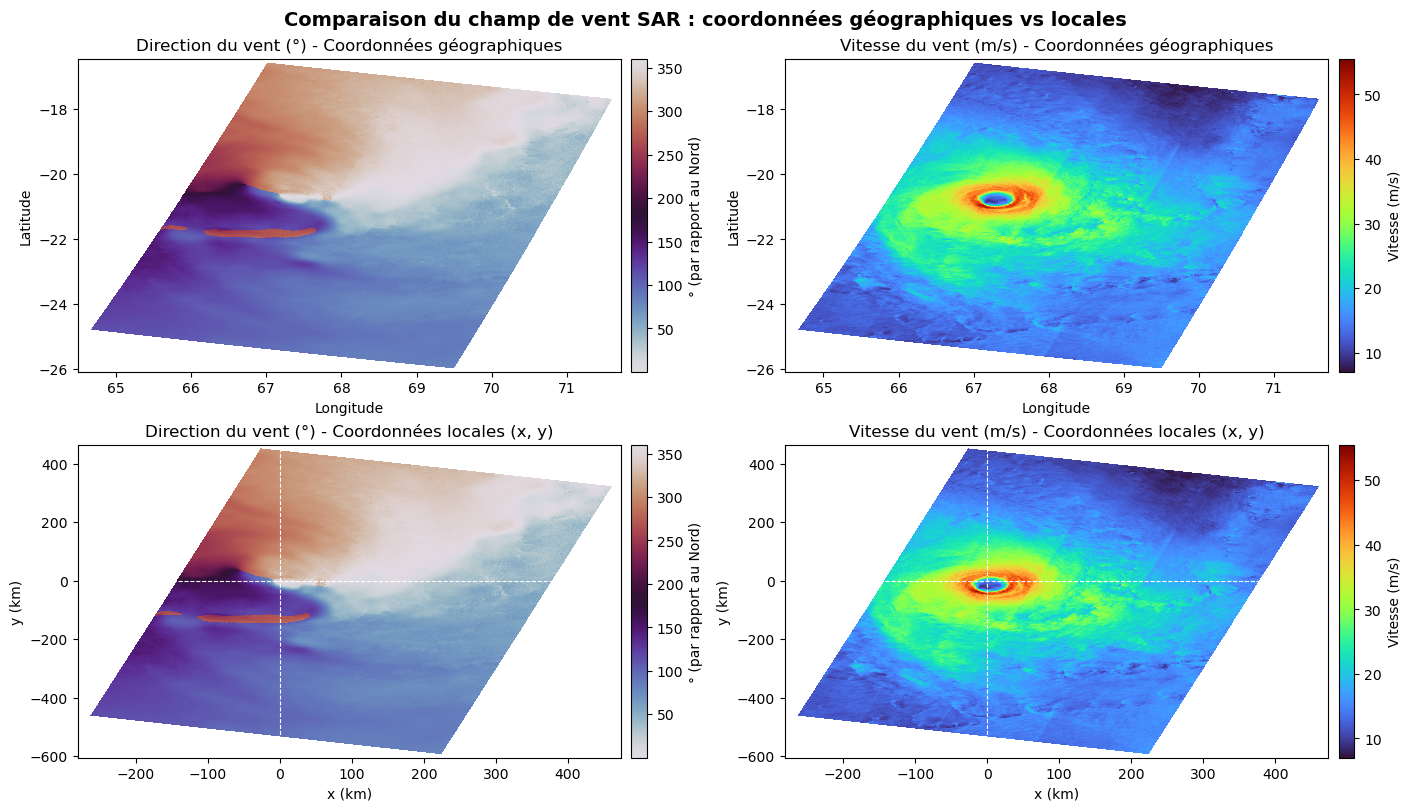

In [31]:
# Création de la figure
i = i+1
sar_xy_exemple_file_path = os.listdir("donnees_sar_changes")[i]
ds_sar_xy = xr.open_dataset("donnees_sar_changes/" + sar_xy_exemple_file_path)
fig, axes = plt.subplots(2, 2, figsize=(14, 8), constrained_layout=True)

# --- 1️⃣ Coordonnées géographiques ---
im00 = axes[0,0].pcolormesh(
    ds_sar_xy["owiLon"], ds_sar_xy["owiLat"],
    ds_sar_xy["owiWindDirection"], cmap="twilight", shading='auto'
)
axes[0,0].set_title("Direction du vent (°) - Coordonnées géographiques", fontsize=12)
axes[0,0].set_xlabel("Longitude")
axes[0,0].set_ylabel("Latitude")
cbar00 = fig.colorbar(im00, ax=axes[0,0], orientation="vertical", pad=0.02)
cbar00.set_label("° (par rapport au Nord)", rotation=90)

# --- 2️⃣ Coordonnées géographiques ---
im01 = axes[0,1].pcolormesh(
    ds_sar_xy["owiLon"], ds_sar_xy["owiLat"],
    ds_sar_xy["owiWindSpeed"], cmap="turbo", shading='auto'
)
axes[0,1].set_title("Vitesse du vent (m/s) - Coordonnées géographiques", fontsize=12)
axes[0,1].set_xlabel("Longitude")
axes[0,1].set_ylabel("Latitude")
cbar01 = fig.colorbar(im01, ax=axes[0,1], orientation="vertical", pad=0.02)
cbar01.set_label("Vitesse (m/s)", rotation=90)

# --- 3️⃣ Coordonnées locales (centrées cyclone) ---
im10 = axes[1,0].pcolormesh(
    ds_sar_xy["x_sar"], ds_sar_xy["y_sar"],
    ds_sar_xy["owiWindDirection"], cmap="twilight", shading='auto'
)
axes[1,0].set_title("Direction du vent (°) - Coordonnées locales (x, y)", fontsize=12)
axes[1,0].set_xlabel("x (km)")
axes[1,0].set_ylabel("y (km)")
axes[1,0].axhline(0, color='white', linestyle='--', linewidth=0.8)
axes[1,0].axvline(0, color='white', linestyle='--', linewidth=0.8)
cbar10 = fig.colorbar(im10, ax=axes[1,0], orientation="vertical", pad=0.02)
cbar10.set_label("° (par rapport au Nord)", rotation=90)

# --- 4️⃣ Coordonnées locales ---
im11 = axes[1,1].pcolormesh(
    ds_sar_xy["x_sar"], ds_sar_xy["y_sar"],
    ds_sar_xy["owiWindSpeed"], cmap="turbo", shading='auto'
)
axes[1,1].set_title("Vitesse du vent (m/s) - Coordonnées locales (x, y)", fontsize=12)
axes[1,1].set_xlabel("x (km)")
axes[1,1].set_ylabel("y (km)")
axes[1,1].axhline(0, color='white', linestyle='--', linewidth=0.8)
axes[1,1].axvline(0, color='white', linestyle='--', linewidth=0.8)
cbar11 = fig.colorbar(im11, ax=axes[1,1], orientation="vertical", pad=0.02)
cbar11.set_label("Vitesse (m/s)", rotation=90)

# --- Ajustement global ---
fig.suptitle("Comparaison du champ de vent SAR : coordonnées géographiques vs locales", fontsize=14, fontweight='bold')
plt.show()